In [1]:
import pandas
from collections import Counter
from matplotlib import pyplot as plt

In [2]:
df = pandas.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [4]:
len(df), len(df.columns)

(8807, 12)

There are 8807 rows and 12 columns in this dataset.
The first column we have here is the `type` column. So lets look at what it is all about.

In [5]:
type_count = Counter(df['type']).most_common()
type_count

[('Movie', 6131), ('TV Show', 2676)]

We can visualize this on a pie-chart

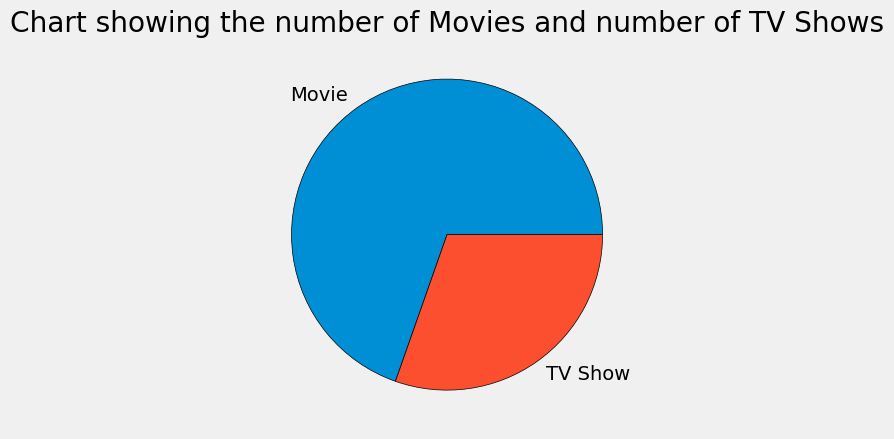

In [6]:
plt.style.use('fivethirtyeight')
slices = [i[1] for i in type_count]
labels = [i[0] for i in type_count]
wedgeprops = {'edgecolor':'black'}
plt.pie(slices, labels=labels, wedgeprops=wedgeprops)
plt.title('Chart showing the number of Movies and number of TV Shows')
plt.show()

Also, on a bar chart

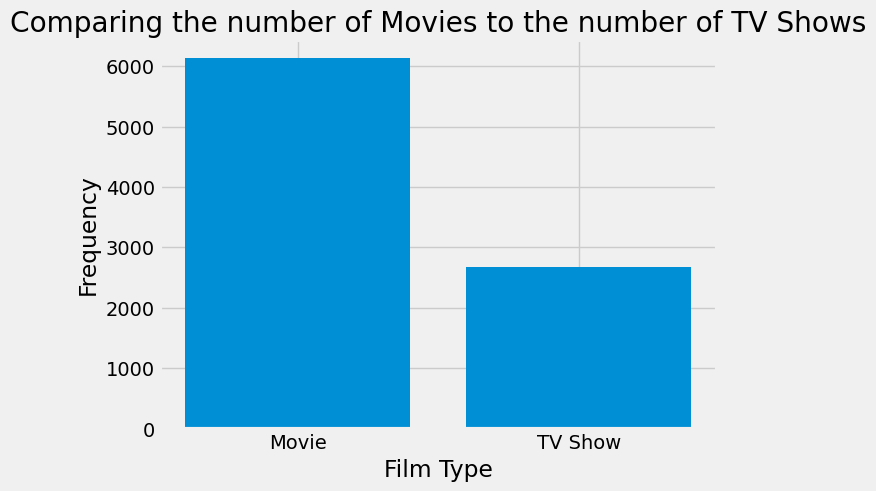

In [7]:

plt.style.use('fivethirtyeight')
plt.bar([i[0] for i in type_count], [j[1] for j in type_count])

plt.title('Comparing the number of Movies to the number of TV Shows')
plt.xlabel('Film Type')
plt.ylabel('Frequency')
plt.show()

The `type` column gives the type drama available on the dataset. There are two main types available here. One of them is `Movie` which appears a total of 6131 times and `TV Show` which appears 2676 times.

The next column here is the `director` column. This column contains all the directors in the dataset

In [8]:
Counter(df['director'])

Counter({nan: 2634,
         'Rajiv Chilaka': 19,
         'Raúl Campos, Jan Suter': 18,
         'Suhas Kadav': 16,
         'Marcus Raboy': 16,
         'Jay Karas': 14,
         'Cathy Garcia-Molina': 13,
         'Youssef Chahine': 12,
         'Martin Scorsese': 12,
         'Jay Chapman': 12,
         'Steven Spielberg': 11,
         'Don Michael Paul': 10,
         'David Dhawan': 9,
         'Quentin Tarantino': 8,
         'Robert Rodriguez': 8,
         'Yılmaz Erdoğan': 8,
         'Hakan Algül': 8,
         'Fernando Ayllón': 8,
         'Troy Miller': 8,
         'Kunle Afolayan': 8,
         'Ryan Polito': 8,
         'Shannon Hartman': 8,
         'Lance Bangs': 8,
         'Johnnie To': 8,
         'Toshiya Shinohara': 7,
         'Prakash Satam': 7,
         'Clint Eastwood': 7,
         'Ram Gopal Varma': 7,
         'McG': 7,
         'Hidenori Inoue': 7,
         'Mae Czarina Cruz': 7,
         'Ozan Açıktan': 7,
         'Ron Howard': 7,
         'Justin G. Dyck': 

There are a lot of missing values in the `director` column. We can handle this by replacing the missing values with something else. In this case, we will replace them with a string of "Missing"

In [9]:
df['director'].fillna('Missing', inplace=True)
director_count = Counter(df['director']).most_common(6)
director_count

C:\Users\Admin\AppData\Local\Temp\ipykernel_5488\1791964892.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Missing', inplace=True)


[('Missing', 2634),
 ('Rajiv Chilaka', 19),
 ('Raúl Campos, Jan Suter', 18),
 ('Suhas Kadav', 16),
 ('Marcus Raboy', 16),
 ('Jay Karas', 14)]

As we can see, there are 2634 missing values from the `director` column.

The top five directors present in this dataset are
Rajiv Chilaka directing 19 movies
Raul Campos and Jan Suter worked together to direct 18 movies
Suhas Kadav directed 16 movies
Marcus Raboy directed 16 movies and
Jay Karas directed 14 movies.

We can also visualize this data

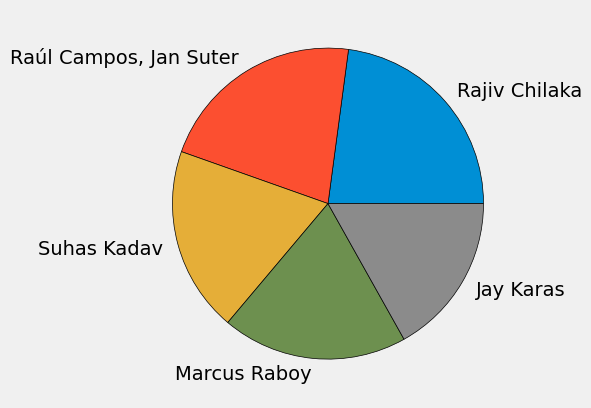

In [10]:
plt.style.use('fivethirtyeight')
slices = [number[1] for number in director_count[1:]]
labels = [name[0] for name in director_count[1:]]
wedgeprops = {'edgecolor': 'black'}
plt.pie(slices, labels=labels, wedgeprops=wedgeprops)
plt.show()

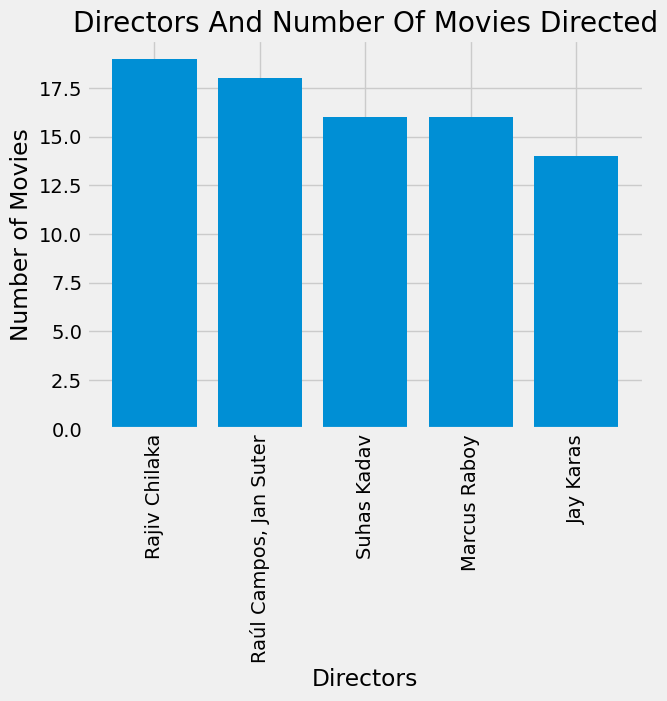

In [11]:
plt.style.use('fivethirtyeight')
plt.bar([name[0] for name in director_count[1:]], [number[1] for number in director_count[1:]])
plt.title('Directors and number of movies directed'.title())
plt.xlabel('Directors')
plt.ylabel('Number of Movies')
plt.xticks(rotation=90)
plt.show()

Next, lets look at the `cast` type

In [12]:
df['cast'].fillna('Missing, Cast', inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5488\3114574662.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cast'].fillna('Missing, Cast', inplace=True)


In [13]:
def get_cast(dataframe):
    nested_list = [i.split(',') for i in dataframe['cast']]
    actors_list = []
    for i in nested_list:
        actors_list.extend(i)
    return actors_list

In [14]:
actors_count = Counter(get_cast(df)).most_common(7)[2:]
actors_count

[(' Anupam Kher', 39),
 (' Rupa Bhimani', 31),
 (' Takahiro Sakurai', 30),
 (' Julie Tejwani', 28),
 (' Om Puri', 27)]

There are 825 missing values on the dataset.
On the list of appearances,
Anupam Kher came first with appearances in 39 movies
Rupa Bhimani came second with 31 appearnaces
Takahiro Sakurai came third with 30 appearances
On the fourth place is Julie Tejwani with 28 appearances and 
On the fifth place is Om Puri with 27 appearances

Now, we want to check which actor appears the most on movies and on TV Shows

In [15]:
def get_cast_by_type(type):
    type_df = df.loc[df['type'] == type]
    return get_cast(type_df)

In [16]:
Counter(get_cast_by_type('Movie')).most_common(7)[2:]

[(' Anupam Kher', 38),
 (' Rupa Bhimani', 27),
 (' Om Puri', 27),
 ('Shah Rukh Khan', 26),
 (' Boman Irani', 25)]

Anupam Kher emerged the most feature Movie star with 38 appearnces,
On the second place are Rupa Bhimani and Om Puri with 27 appearances,
Fourth on the list is Shah Rukh Khan with 26 appearances and
On the fifth place is Boman Irani with 25 appearances.

In [17]:
Counter(get_cast_by_type('TV Show')).most_common(7)[2:]

[(' Takahiro Sakurai', 24),
 (' Junichi Suwabe', 17),
 (' Ai Kayano', 17),
 (' Yuki Kaji', 17),
 (' Daisuke Ono', 14)]

Takahiro Sakurai came first as the most featured TV Show star with 24 appearances
Junichi Suwabe, Ai Kayano and Yuki Kaji came second with 17 appearances
Then on the fifth place is Daisuke Ono with 14 appearances


Now, let's check the country with the most stars, movie stars, tv show stars, movies and tv shows

Let's begin with country

In [18]:
df['country'].fillna('NoCountry', inplace=True)
country_count = Counter(df['country'])
top_fifteen_countries = country_count.most_common(16)
top_fifteen_countries.pop(2)
top_fifteen_countries

C:\Users\Admin\AppData\Local\Temp\ipykernel_5488\940628367.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('NoCountry', inplace=True)


[('United States', 2818),
 ('India', 972),
 ('United Kingdom', 419),
 ('Japan', 245),
 ('South Korea', 199),
 ('Canada', 181),
 ('Spain', 145),
 ('France', 124),
 ('Mexico', 110),
 ('Egypt', 106),
 ('Turkey', 105),
 ('Nigeria', 95),
 ('Australia', 87),
 ('Taiwan', 81),
 ('Indonesia', 79)]

Now, we want to check the type of show by country

In [19]:
def show(country):
    country_df = df.loc[df['country'] == country]
    show_count = Counter(country_df['type']).most_common()
    return show_count

In [20]:
countries = [i[0] for i in top_fifteen_countries]
for i in countries:
    print(f'{i}: {show(i)}')

United States: [('Movie', 2058), ('TV Show', 760)]
India: [('Movie', 893), ('TV Show', 79)]
United Kingdom: [('TV Show', 213), ('Movie', 206)]
Japan: [('TV Show', 169), ('Movie', 76)]
South Korea: [('TV Show', 158), ('Movie', 41)]
Canada: [('Movie', 122), ('TV Show', 59)]
Spain: [('Movie', 97), ('TV Show', 48)]
France: [('Movie', 75), ('TV Show', 49)]
Mexico: [('Movie', 70), ('TV Show', 40)]
Egypt: [('Movie', 92), ('TV Show', 14)]
Turkey: [('Movie', 76), ('TV Show', 29)]
Nigeria: [('Movie', 86), ('TV Show', 9)]
Australia: [('TV Show', 48), ('Movie', 39)]
Taiwan: [('TV Show', 68), ('Movie', 13)]
Indonesia: [('Movie', 77), ('TV Show', 2)]


We can represent the data above in tabular form

In [21]:


country_show = {
    'Country': countries,
    'Movie': [show(country)[0][1] for country in countries],
    'TV Show': [show(country)[1][1] for country in countries]
}

country_show_df = pandas.DataFrame(country_show)
country_show_df['Total'] = country_show_df['Movie'] + country_show_df['TV Show']
country_show_df['MoviePercent'] = (country_show_df['Movie']/country_show_df['Total']) * 100
country_show_df['TV ShowPercent'] = (country_show_df['TV Show']/country_show_df['Total']) * 100


In [22]:
country_show_df

,Country,Movie,TV Show,Total,MoviePercent,TV ShowPercent
0,United States,2058,760,2818,73.030518,26.969482
1,India,893,79,972,91.872428,8.127572
2,United Kingdom,213,206,419,50.835322,49.164678
3,Japan,169,76,245,68.979592,31.020408
4,South Korea,158,41,199,79.396985,20.603015
5,Canada,122,59,181,67.403315,32.596685
6,Spain,97,48,145,66.896552,33.103448
7,France,75,49,124,60.483871,39.516129
8,Mexico,70,40,110,63.636364,36.363636
9,Egypt,92,14,106,86.792453,13.207547


In [23]:
country_show_df.sort_values(by='TV ShowPercent', ascending=False, ignore_index=True)

,Country,Movie,TV Show,Total,MoviePercent,TV ShowPercent
0,United Kingdom,213,206,419,50.835322,49.164678
1,Australia,48,39,87,55.172414,44.827586
2,France,75,49,124,60.483871,39.516129
3,Mexico,70,40,110,63.636364,36.363636
4,Spain,97,48,145,66.896552,33.103448
5,Canada,122,59,181,67.403315,32.596685
6,Japan,169,76,245,68.979592,31.020408
7,Turkey,76,29,105,72.380952,27.619048
8,United States,2058,760,2818,73.030518,26.969482
9,South Korea,158,41,199,79.396985,20.603015


In [24]:
country_show_df.sort_values(by='MoviePercent', ascending=False, ignore_index=True)

,Country,Movie,TV Show,Total,MoviePercent,TV ShowPercent
0,Indonesia,77,2,79,97.468354,2.531646
1,India,893,79,972,91.872428,8.127572
2,Nigeria,86,9,95,90.526316,9.473684
3,Egypt,92,14,106,86.792453,13.207547
4,Taiwan,68,13,81,83.950617,16.049383
5,South Korea,158,41,199,79.396985,20.603015
6,United States,2058,760,2818,73.030518,26.969482
7,Turkey,76,29,105,72.380952,27.619048
8,Japan,169,76,245,68.979592,31.020408
9,Canada,122,59,181,67.403315,32.596685


Now, let us look at stars by country. First of all, we want to look at the country with the highest stars

In [25]:
def get_cast_by_country(country):
    country_df = df.loc[df['country'] == country]
    return get_cast(country_df)

In [26]:
for country in countries:
    print(f'{country}: {len(Counter(get_cast_by_country(country)).most_common())}')

United States: 12556
India: 3905
United Kingdom: 1704
Japan: 1327
South Korea: 1181
Canada: 1020
Spain: 886
France: 714
Mexico: 765
Egypt: 513
Turkey: 646
Nigeria: 527
Australia: 514
Taiwan: 447
Indonesia: 481


In [27]:
country_cast = {
    'Country': countries,
    'Stars': [len(Counter(get_cast_by_country(c)).most_common()) for c in countries]
}
country_cast_df = pandas.DataFrame(country_cast)
country_cast_df

,Country,Stars
0,United States,12556
1,India,3905
2,United Kingdom,1704
3,Japan,1327
4,South Korea,1181
5,Canada,1020
6,Spain,886
7,France,714
8,Mexico,765
9,Egypt,513


Let us now take a look at the `release_year` column

In [28]:
def visualize_movie_by_year(dataframe, all_shows='All Plays'):
    movie_year_count = Counter(dataframe['release_year']).most_common(20)

    movie_year = {
        'Year': [i[0] for i in movie_year_count],
        'NumberOfMovies': [i[1] for i in movie_year_count]
    }
    movie_year_df = pandas.DataFrame(movie_year)
    movie_year_df.sort_values(by='Year', ignore_index=True, inplace=True)

    plt.style.use('fivethirtyeight')
    plt.plot([str(i) for i in movie_year_df['Year']], movie_year_df['NumberOfMovies'])
    plt.title(f'{all_shows} produced each year'.title())
    plt.xlabel('Year Produced')
    plt.ylabel('Number of Movies')
    plt.xticks(rotation=90)
    plt.show()
    return movie_year_df

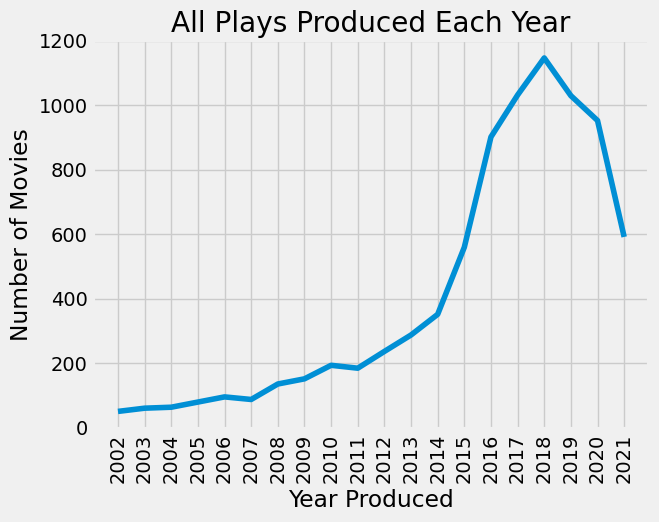

,Year,NumberOfMovies
0,2002,51
1,2003,61
2,2004,64
3,2005,80
4,2006,96
5,2007,88
6,2008,136
7,2009,152
8,2010,194
9,2011,185


In [29]:
visualize_movie_by_year(df)

Globally, the amount of movies released each year kept increasing till it got to an all time high in 2018 and began dropping from 2019.
Using the `visualize_movie_by_year` function, we check how the amount of movies released fared for each country.

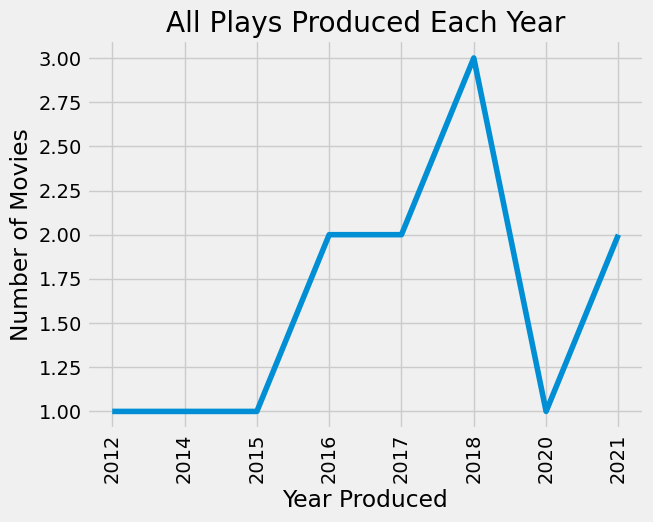

,Year,NumberOfMovies
0,2012,1
1,2014,1
2,2015,1
3,2016,2
4,2017,2
5,2018,3
6,2020,1
7,2021,2


In [30]:
country_df = df.loc[df['country'] == 'Israel']
visualize_movie_by_year(country_df)


Now, we extend our search to the number of TV Shows and Movies produced each year.
Let's begin with movies.

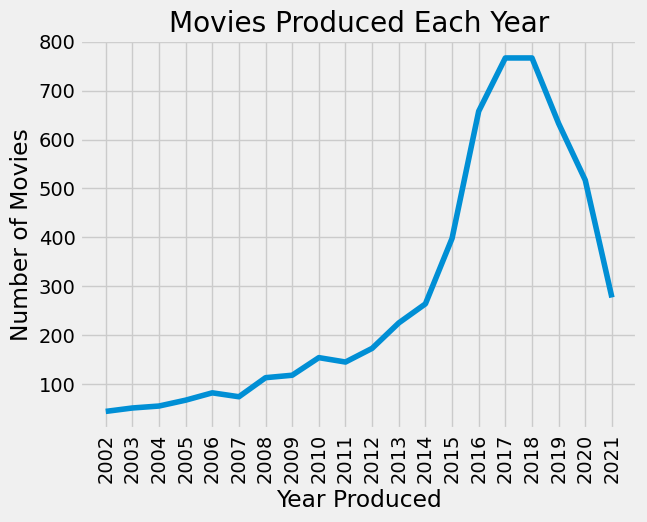

,Year,NumberOfMovies
0,2002,44
1,2003,51
2,2004,55
3,2005,67
4,2006,82
5,2007,74
6,2008,113
7,2009,118
8,2010,154
9,2011,145


In [31]:
movie_df = df.loc[df['type'] == 'Movie']
visualize_movie_by_year(movie_df, all_shows='Movies')

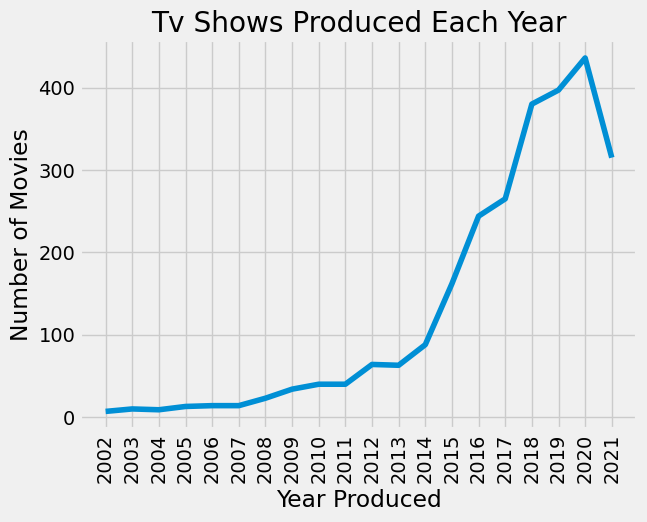

,Year,NumberOfMovies
0,2002,7
1,2003,10
2,2004,9
3,2005,13
4,2006,14
5,2007,14
6,2008,23
7,2009,34
8,2010,40
9,2011,40


In [32]:
tv_shows_df = df.loc[df['type'] == 'TV Show']
visualize_movie_by_year(tv_shows_df, all_shows='Tv Shows')

For now, these are the information we could obtain from the dataset. We will still continue to check for areas and columns we did nothing on and get their contributions to the dataset analysis and the results